In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy import stats
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox



plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [106]:
ruta = "/Users/bautistagianfrancisco/Library/Mobile Documents/com~apple~CloudDocs/MIA 2026/2 Trim/Modelado Estocastico/Bases de Datos MIA103/Precios_y_Dinero.xlsx"

PyD = pd.read_excel(
    ruta,
    sheet_name="Hoja1"
)

PyD.head()

,MMYY,IPC,M,M_en_ARS
0,2003-01-01,100.000000,100.000000,29609.920333
1,2003-02-01,100.566796,99.359830,29420.366429
2,2003-03-01,101.155116,102.628052,30388.084290
3,2003-04-01,101.212513,104.258927,30870.985333
4,2003-05-01,100.817908,111.804321,33105.170323


In [107]:
PyD.columns = PyD.columns.str.strip()
PyD.columns

Index(['MMYY', 'IPC', 'M', 'M_en_ARS'], dtype='object')

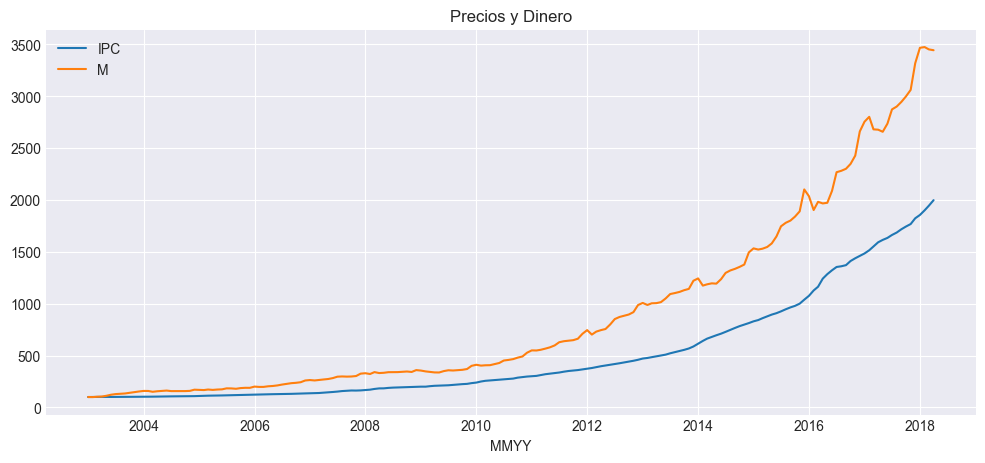

In [108]:

plt.plot(PyD['MMYY'],PyD['IPC'],label='IPC')
plt.plot(PyD['MMYY'],PyD['M'],label='M')

plt.title('Precios y Dinero')
plt.xlabel('MMYY')

plt.legend()
plt.show()

Que hubo un aumento significativo de la base monetaria por encima del IPC a lo largo del tiempo y que hay correlacion entre estos. 

Como IPC y M están en niveles y presentan tendencia, no trabajo directamente con esas series. Siguiendo la lógica de las clases 7 y 8, uso diferencias logarítmicas para obtener tasas: inflación como Δln(IPC) y crecimiento monetario como Δln(M), multiplicadas por 100.

# Ejercicio 2

In [109]:
PyD["IPC"] = pd.to_numeric(
    PyD["IPC"],
    errors="coerce"
)

ipc = PyD["IPC"].dropna()

In [110]:
test_ipc = adfuller(
    ipc,
    regression="ct",
    autolag="t-stat"
)

print("Estadístico ADF:", test_ipc[0])
print("p-value:", test_ipc[1])
print("Rezagos:", test_ipc[2])
print("Observaciones:", test_ipc[3])
print("Valores críticos:", test_ipc[4])

Estadístico ADF: 4.563510046583303
p-value: 1.0
Rezagos: 7
Observaciones: 176
Valores críticos: {'1%': np.float64(-4.0111504185278335), '5%': np.float64(-3.435735487048624), '10%': np.float64(-3.1418717251772637)}


El ADF sobre IPC en niveles no permite rechazar la hipótesis nula de raíz unitaria, porque el p-value es mayor que 0.05. Por lo tanto, IPC no es I(0) en niveles.

In [111]:
d_ipc = ipc.diff().dropna()

In [112]:
test_d_ipc = adfuller(
    d_ipc,
    regression="c",
    autolag="t-stat"
)

print("Estadístico ADF:", test_d_ipc[0])
print("p-value:", test_d_ipc[1])
print("Rezagos:", test_d_ipc[2])
print("Observaciones:", test_d_ipc[3])
print("Valores críticos:", test_d_ipc[4])

Estadístico ADF: 0.3270847887660001
p-value: 0.9785535607817413
Rezagos: 8
Observaciones: 174
Valores críticos: {'1%': np.float64(-3.4685016947910636), '5%': np.float64(-2.8782983668563396), '10%': np.float64(-2.57570415906989)}


El ADF sobre la primera diferencia de IPC tampoco permite rechazar la hipótesis nula de raíz unitaria. Por lo tanto, ΔIPC no es I(0).

In [113]:
dd_ipc = d_ipc.diff().dropna()

In [114]:
test_dd_ipc = adfuller(
    dd_ipc,
    regression="c",
    autolag="t-stat"
)

print("Estadístico ADF:", test_dd_ipc[0])
print("p-value:", test_dd_ipc[1])
print("Rezagos:", test_dd_ipc[2])
print("Observaciones:", test_dd_ipc[3])
print("Valores críticos:", test_dd_ipc[4])

Estadístico ADF: -7.368282328173161
p-value: 9.113361917991752e-11
Rezagos: 7
Observaciones: 174
Valores críticos: {'1%': np.float64(-3.4685016947910636), '5%': np.float64(-2.8782983668563396), '10%': np.float64(-2.57570415906989)}


El ADF sobre la segunda diferencia de IPC rechaza la hipótesis nula de raíz unitaria al 5%, ya que el p-value es menor que 0.05. Por lo tanto, la segunda diferencia de IPC puede considerarse estacionaria.

Como IPC no es estacionaria en niveles, su primera diferencia tampoco es estacionaria, pero su segunda diferencia sí lo es, concluyo que IPC es integrada de orden 2, es decir:

IPC ~ I(2).

El test ADF aplicado a IPC en niveles no rechaza la hipótesis nula de raíz unitaria. Luego, al aplicar el test sobre la primera diferencia de IPC, tampoco se rechaza la hipótesis nula. Finalmente, al aplicar el test sobre la segunda diferencia de IPC, el p-value es menor a 0.05, por lo que rechazo la hipótesis nula de raíz unitaria.

Por lo tanto, la segunda diferencia de IPC es estacionaria. Concluyo que IPC es integrada de orden 2:

IPC ~ I(2).

# Ejercicio 3

In [115]:
PyD["M"] = pd.to_numeric(
    PyD["M"],
    errors="coerce"
)

m = PyD["M"].dropna()

In [116]:
test_m = adfuller(
    m,
    regression="ct",
    autolag="t-stat"
)

print("Estadístico ADF:", test_m[0])
print("p-value:", test_m[1])
print("Rezagos:", test_m[2])
print("Observaciones:", test_m[3])
print("Valores críticos:", test_m[4])

Estadístico ADF: 3.945240274115594
p-value: 1.0
Rezagos: 12
Observaciones: 171
Valores críticos: {'1%': np.float64(-4.012711131704242), '5%': np.float64(-3.4364829463776627), '10%': np.float64(-3.1423091729829)}


no rechazo, ahora tomo diferencias.

In [117]:
d_m = m.diff().dropna()

test_d_m = adfuller(
    d_m,
    regression="c",
    autolag="t-stat"
)

print("Estadístico ADF:", test_d_m[0])
print("p-value:", test_d_m[1])
print("Rezagos:", test_d_m[2])
print("Observaciones:", test_d_m[3])
print("Valores críticos:", test_d_m[4])

Estadístico ADF: 0.8409495074661382
p-value: 0.9922692241359653
Rezagos: 13
Observaciones: 169
Valores críticos: {'1%': np.float64(-3.469648263987657), '5%': np.float64(-2.878798906308495), '10%': np.float64(-2.5759713094779593)}


no rechazo a nivel 5%

In [118]:
dd_m = d_m.diff().dropna()

test_dd_m = adfuller(
    dd_m,
    regression="c",
    autolag="t-stat"
)

print("Estadístico ADF:", test_dd_m[0])
print("p-value:", test_dd_m[1])
print("Rezagos:", test_dd_m[2])
print("Observaciones:", test_dd_m[3])
print("Valores críticos:", test_dd_m[4])

Estadístico ADF: -9.81417587622779
p-value: 5.554205778299402e-17
Rezagos: 12
Observaciones: 169
Valores críticos: {'1%': np.float64(-3.469648263987657), '5%': np.float64(-2.878798906308495), '10%': np.float64(-2.5759713094779593)}


Ahora si rechazo, M es I(2) 

# Ejercicio 4

In [119]:
PyD["IPC"] = pd.to_numeric(PyD["IPC"], errors="coerce")
PyD["M"] = pd.to_numeric(PyD["M"], errors="coerce")

In [120]:
PyD["log_ipc"] = np.log(PyD["IPC"])
PyD["log_m"] = np.log(PyD["M"])


PyD["inflacion"] = PyD["log_ipc"].diff()
PyD["crec_m"] = PyD["log_m"].diff()

PyD.head()

,MMYY,IPC,M,M_en_ARS,log_ipc,log_m,inflacion,crec_m
0,2003-01-01,100.000000,100.000000,29609.920333,4.605170,4.605170,NaN,NaN
1,2003-02-01,100.566796,99.359830,29420.366429,4.610822,4.598748,0.005652,-0.006422
2,2003-03-01,101.155116,102.628052,30388.084290,4.616655,4.631111,0.005833,0.032363
3,2003-04-01,101.212513,104.258927,30870.985333,4.617222,4.646877,0.000567,0.015766
4,2003-05-01,100.817908,111.804321,33105.170323,4.613316,4.716750,-0.003906,0.069873


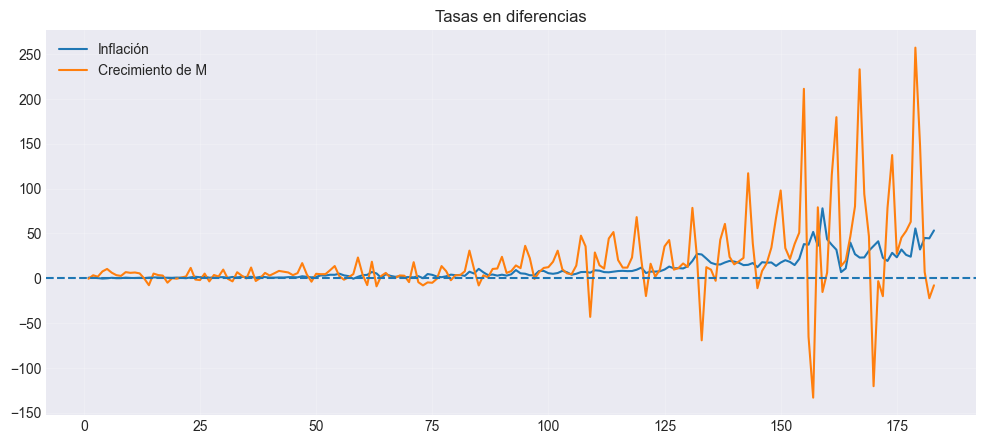

In [87]:
fig, ax = plt.subplots(figsize=(12, 5))

PyD["inflacion"].plot(ax=ax, label="Inflación")
PyD["crec_m"].plot(ax=ax, label="Crecimiento de M")

ax.set_title("Tasas en diferencias")
ax.set_xlabel("")
ax.axhline(0, linestyle="--")
ax.legend()
ax.grid(alpha=0.2)

plt.show()

In [121]:
PyD["inflacion"] = pd.to_numeric(
    PyD["inflacion"],
    errors="coerce"
)

inf = PyD["inflacion"].dropna()

In [122]:
test_m = adfuller(
    inf,
    regression="ct",
    autolag="t-stat"
)

print("Estadístico ADF:", test_m[0])
print("p-value:", test_m[1])
print("Rezagos:", test_m[2])
print("Observaciones:", test_m[3])
print("Valores críticos:", test_m[4])

Estadístico ADF: -7.714192038718388
p-value: 3.269789162616602e-10
Rezagos: 0
Observaciones: 182
Valores críticos: {'1%': np.float64(-4.009392790586421), '5%': np.float64(-3.434893396561173), '10%': np.float64(-3.141378799874199)}


Rechazo I(0)


In [125]:
PyD["crec_m"] = pd.to_numeric(
    PyD["crec_m"],
    errors="coerce"
)

crecm = PyD["crec_m"].dropna()

In [126]:
test_m = adfuller(
    crecm,
    regression="ct",
    autolag="t-stat"
)

print("Estadístico ADF:", test_m[0])
print("p-value:", test_m[1])
print("Rezagos:", test_m[2])
print("Observaciones:", test_m[3])
print("Valores críticos:", test_m[4])

Estadístico ADF: -3.8830139882902404
p-value: 0.012801048187398705
Rezagos: 11
Observaciones: 171
Valores críticos: {'1%': np.float64(-4.012711131704242), '5%': np.float64(-3.4364829463776627), '10%': np.float64(-3.1423091729829)}


# Ejercicio 5

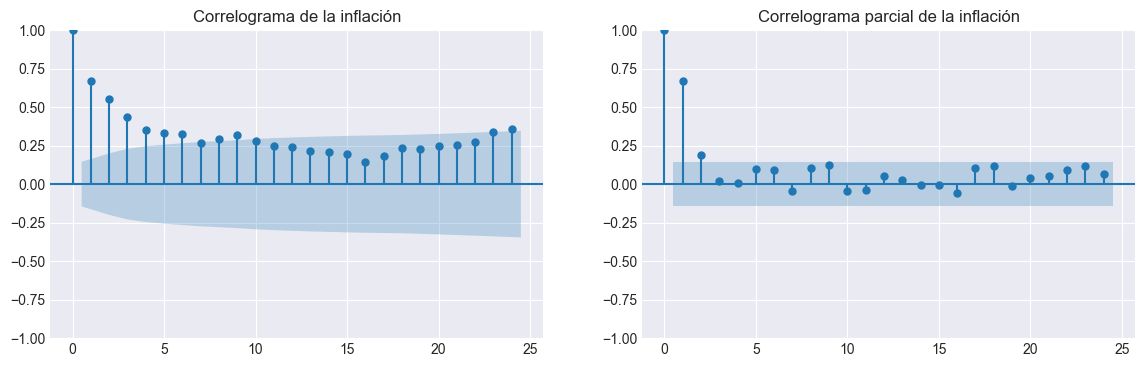

In [128]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(inf, lags=24, ax=ax[0])
plot_pacf(inf, lags=24, ax=ax[1], method="ywm")

ax[0].set_title("Correlograma de la inflación")
ax[1].set_title("Correlograma parcial de la inflación")

plt.show()

El correlograma de la inflación muestra autocorrelaciones positivas que decrecen gradualmente. No se observa un corte abrupto en la ACF, por lo que no parece una media móvil pura.

El correlograma parcial muestra un pico claramente significativo en el rezago 1 y luego las autocorrelaciones parciales caen bastante. El rezago 2 también parece algo relevante, pero mucho menor que el primero.

Por lo tanto, la serie de inflación parece tener una estructura principalmente autorregresiva. Una primera aproximación razonable sería un AR(1), aunque podría considerarse también un AR(2) como alternativa.

# Ejercicio 6

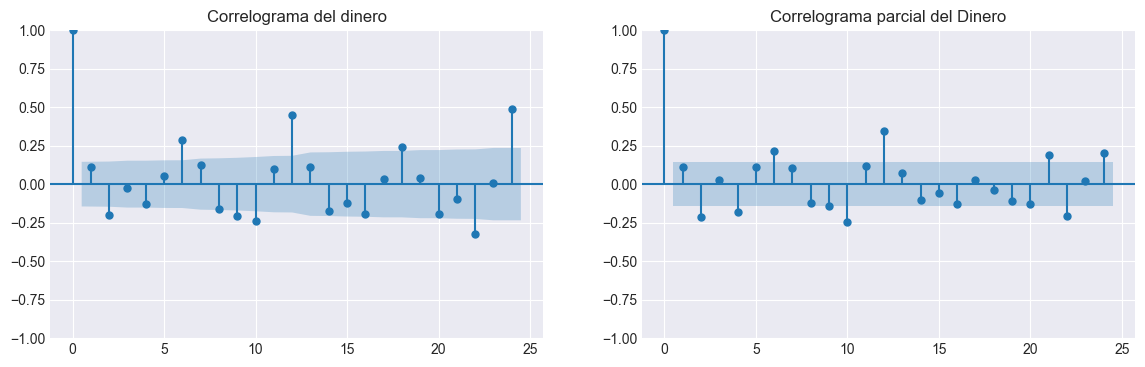

In [129]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(crecm, lags=24, ax=ax[0])
plot_pacf(crecm, lags=24, ax=ax[1], method="ywm")

ax[0].set_title("Correlograma del dinero")
ax[1].set_title("Correlograma parcial del Dinero")

plt.show()

El correlograma de crec_m no muestra una caída suave típica de un AR simple ni un corte claro típico de un MA puro. Aparecen autocorrelaciones relevantes en rezagos específicos, especialmente alrededor de 6, 12 y 24 meses.

El correlograma parcial tampoco presenta un corte limpio: hay varios rezagos que parecen relevantes, incluyendo algunos rezagos largos. Esto sugiere que la dinámica de crec_m no se resume bien con un AR o MA de bajo orden.

Por lo tanto, crec_m no parece seguir claramente un AR(p) o MA(q) simple. La presencia de picos en rezagos como 12 y 24 sugiere posible componente estacional o dinámica mensual más compleja.

# Ejercicio 7

In [134]:
data = PyD[["inflacion", "crec_m"]].dropna()

y = data["inflacion"]
X = sm.add_constant(data["crec_m"])

reg = sm.OLS(y, X).fit()

print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:              inflacion   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.3392
Date:                Thu, 27 Aug 2026   Prob (F-statistic):              0.561
Time:                        08:42:57   Log-Likelihood:                 577.88
No. Observations:                 183   AIC:                            -1152.
Df Residuals:                     181   BIC:                            -1145.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0167      0.001     18.043      0.0

Se corre una regresión simple donde la variable dependiente es inflación y la variable independiente es crec_m, incluyendo una constante. Ambas variables fueron definidas como diferencias logarítmicas y, según los tests ADF anteriores, pueden considerarse I(0), por lo que tienen el mismo orden de integración.

El coeficiente estimado de crec_m es negativo y no es estadísticamente significativo, ya que su p-value es mayor que 0.05. Por lo tanto, a partir de esta regresión simple no podemos afirmar que una mayor tasa de crecimiento de la base monetaria genere mayor inflación.

Además, esta regresión muestra una relación contemporánea, no una relación causal. Para hablar de causalidad en series de tiempo habría que incorporar dinámica, por ejemplo rezagos, o aplicar un test de causalidad de Granger.

In [135]:
print("Durbin-Watson:", durbin_watson(reg.resid))

acorr_ljungbox(
    reg.resid,
    lags=[1, 6, 12],
    return_df=True
)

Durbin-Watson: 0.6623027075339861


,lb_stat,lb_pvalue
1,81.745045,1.548242e-19
6,241.919952,2.183654e-49
12,334.689471,2.371791e-64


El estadístico Durbin-Watson es aproximadamente 0.66, bastante menor que 2, lo que sugiere autocorrelación positiva en los residuos. Además, el test de Ljung-Box arroja p-values muy bajos, por lo que se rechaza la hipótesis nula de no autocorrelación.

Esto indica que los residuos están autocorrelacionados y que la regresión simple está omitiendo dinámica temporal relevante.

Si los residuos están autocorrelacionados, no conviene quedarse con esta regresión estática. Una alternativa sería incluir rezagos de inflación y de crec_m, estimar un modelo dinámico, o trabajar con un VAR. La idea es capturar la dependencia temporal para que los residuos se parezcan más a ruido blanco.

# Ejercitacion 7